# Проверка проекта

Я буду проверять проект и оставлять комментарии по ходу ноутбука:

- <span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;">Зеленым</span> буду отмечать, что сделано хорошо.
- <span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;">Желтым</span> буду отмечать, что советую поправить, но это не критично.
- <span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;">Красным</span> буду отмечать ошибки, которые обязательно нужно исправить.

# Предобработка данных TAIGA: gamma vs proton

Цель работы: подготовить данные Хилласа к обучению моделей классификации частиц: `gamma` или `proton`.

В этой части работы нужно:

1. Считать CSV-файлы с данными.
2. Проверить структуру и качество данных.
3. Построить распределения признаков для классов `gamma` и `proton`.
4. Исследовать связь признаков с целевым классом.
5. Сформировать итоговый набор признаков для последующего обучения моделей.

## Словарь признаков для текущих CSV

Ниже приведена рабочая расшифровка признаков, которые есть в текущих файлах `data/gamma.csv` и `data/proton.csv` и соотносятся с PDF `Parameters_Definitions_Report.pdf`.

Важное ограничение: PDF описывает более полные экспериментальные таблицы TAIGA-IACT02, а текущие CSV являются сокращёнными таблицами признаков для задачи `gamma` vs `proton`. Поэтому информация из PDF подходит к нашим данным только частично. Хорошо применимы разделы про Hillas-параметры, моменты формы изображения и параметры клининга. В текущих CSV нет многих полей наблюдений, времени, pointing-файлов, фона и темпа счёта: `por`, `time`, `unix_time_ns`, `delta_time`, `error_deg`, `tel_az`, `tel_el`, `source_az`, `source_el`, `CR400phe`, `CR_portion`, `median_background`, `MAD_background`, `tel_ra`, `tel_dec`, `source_ra`, `source_dec`, `tracking`, `good`, `star`, `weather_mark`, `alpha_c`. Поэтому в этой работе используйте только фактически присутствующие колонки.

| Колонка в текущих CSV | Описание |
|---|---|
| `event_number` | Номер события. В PDF: `event_numb`. |
| `numb_pix` | Число пикселей, прошедших клининг. |
| `num_islands` | Число островов в событии после клининга. |
| `size` | Суммарное число фотоэлектронов в событии. |
| `Xc[0]` | X-координата центра тяжести события. |
| `Yc[0]` | Y-координата центра тяжести события. |
| `con_selected_island` | Доля `size` в отобранном самом ярком острове. |
| `con2` | Доля `size` в двух самых ярких пикселях события. |
| `length[0]` | Момент второго порядка вдоль главной оси эллипса. |
| `width[0]` | Момент второго порядка вдоль малой оси эллипса. |
| `dist[0]` | Расстояние между центром тяжести эллипса и положением источника. В PDF: `dist1`. |
| `dist[1]` | Расстояние между центром тяжести эллипса и положением антиисточника. В PDF: `dist2`. |
| `a_axis[0]` | Коэффициент `a` уравнения `y = a*x + b`, характеризующий наклон эллипса относительно координатной сетки камеры. |
| `b_axis[0]` | Коэффициент `b` уравнения `y = a*x + b`. Этого поля нет в исходной таблице описаний, но оно согласуется с описанием `a_axis`. |
| `skewness_l` | Асимметрия события вдоль главной оси эллипса. |
| `skewness_w` | Асимметрия события вдоль малой оси эллипса. |
| `skewness` | Асимметрия события. При анализе нужно проверить, как этот вариант названия соотносится с моментами вдоль осей. |
| `kurtosis_l` | Эксцесс вдоль главной оси. |
| `kurtosis_w` | Эксцесс вдоль малой оси. |
| `kurtosis` | Эксцесс события. При анализе нужно проверить, как этот вариант названия соотносится с моментами вдоль осей. |
| `alpha[0]` | Угол между главной осью эллипса и направлением на источник. В PDF: `alpha1`. |
| `alpha[1]` | Угол между главной осью эллипса и направлением на антиисточник. В PDF: `alpha2`. |
| `source_x` | X-координата источника в камере в градусах. |
| `source_y` | Y-координата источника в камере в градусах. |
| `edge` | Индикатор наличия граничных пикселей камеры среди пикселей, прошедших клининг. |

Колонки без надежного описания из предоставленного словаря, но присутствующие в данных: `clean_number`, `axis_scatter`, `energy`, `azwidth[1]`, `miss[1]`, `x_max_coord`, `y_max_coord`, `x_ground`, `y_ground`, `tel_tet`, `tel_fi`, `source_tet`, `source_fi`, `Xmax`, `con1`, `con3`.

Для итогового выбора признаков важно не только название, но и проверка распределений, пропусков, корреляций и возможной утечки информации.

## Как выполнять работу

- Выполняйте задания строго по порядку.
- В кодовых ячейках даны только подсказки по нужным методам и направлению решения. Рабочий код нужно написать самостоятельно.
- После каждого задания заполните блок `Промежуточный вывод`.
- Не ограничивайтесь фразой "видно на графике". Пишите, какие именно признаки отличаются и почему это важно для будущей модели.
- В конце работы должен получиться список признаков `selected_features`, который можно использовать в следующем ноутбуке для обучения моделей.

## Подготовка окружения

Импортируйте библиотеки, которые понадобятся для анализа таблиц и визуализации.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## Задание 1. Считать CSV-данные

В папке `data` лежат два подготовленных CSV-файла:

- `gamma.csv` - события класса gamma;
- `proton.csv` - события класса proton.

Считайте оба файла в pandas DataFrame и посмотрите первые строки.

In [22]:
# Подсказки:
# 1. Создайте переменные с путями к файлам: data/gamma.csv и data/proton.csv.
# 2. Считайте оба файла с помощью pandas: pd.read_csv(...).
# 3. Сохраните таблицы в переменные gamma и proton.
# 4. Выведите размер таблиц через .shape.
# 5. Посмотрите первые строки через .head() или display(...).

# Ваш код:
path_gamma = 'data/gamma.csv'
path_proton = 'data/proton.csv'

gamma=pd.read_csv(path_gamma)
proton=pd.read_csv(path_proton)

print("Размер таблицы с gamma", gamma.shape)
print("Размер таблицы с proton", proton.shape)

display(gamma.head())
display(proton.head())

Размер таблицы с gamma (6218, 35)
Размер таблицы с proton (5218, 39)


,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
0,0,1,1,21,192.9010,903.418,1.369730,-2.416260,0.343822,0.706498,0.122870,2.77750,2.77758,0.123940,0.064859,1.334930,1.33803,-1.863970,1.134940,1.2663,-2.193290,0.412741,354.0430,1,-0.000172,-3.103450e-10,485.326,171.9310,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0
1,1,1,4,24,192.9010,1388.880,-2.460750,0.711740,0.354539,0.698548,0.166367,2.56161,2.56145,0.166931,0.051739,1.158470,1.15740,-0.311280,-0.449759,-2.1708,0.626656,0.509002,345.2810,1,-0.000172,-3.103450e-10,-159.734,-333.3390,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0
2,2,1,7,13,192.9010,369.733,-0.612322,-3.264150,0.340513,0.551291,0.143484,3.32109,3.32105,0.146999,0.199367,3.438680,3.44160,3.991980,-6.797440,-0.5427,-2.819950,-0.226941,112.9880,0,-0.000172,-3.103450e-10,726.070,-160.2360,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0
3,3,1,9,13,192.9010,455.150,0.261173,3.177410,0.388384,0.542986,0.139691,3.18813,3.18814,0.139691,0.002199,0.036433,0.03952,12.261400,-0.206795,0.1809,2.819950,0.040126,107.7320,0,-0.000172,-3.103450e-10,-680.504,90.0432,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0
4,4,2,1,5,30.2981,119.634,-2.490450,-0.030344,0.566160,0.381089,0.090839,2.49064,2.49049,0.091882,0.092892,2.137600,2.13756,0.049532,0.771256,-2.8944,0.000000,-0.557556,24.1858,0,-0.000145,-2.866540e-10,276.559,-273.8100,0.570295,7.05519,0.570295,0.772003,380.335,1,1.0


,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
0,0,1,0,7,28.4757,169.972,-2.067280,1.696840,0.520998,0.374946,0.113381,2.674490,3.690510,0.223461,1.988420,20.59530,32.6014,-1.730280,-15.589900,-1.9899,1.566640,-0.251106,30.11550,-0.077952,0.719059,0.290089,0.691679,0,1.21,0,169.549,282.65400,0.651756,6.76840,0.603315,0.396753,248.061,1,1.0
1,1,1,2,7,28.4757,91.531,-0.384003,-0.310093,0.452721,0.297078,0.169732,0.493575,1.623880,0.188367,0.544063,8.33836,19.5748,0.591010,-0.689418,-0.1809,-0.313328,-0.012724,9.20917,-0.006222,0.996101,0.257487,0.593733,0,1.21,0,-322.057,164.01700,0.584419,6.72654,0.603315,0.396753,248.061,1,1.0
2,2,5,2,4,16.0010,80.916,-1.476070,0.112919,0.740002,0.178342,0.129863,1.480390,2.688450,0.152468,1.757060,42.77790,40.8105,0.792684,10.638300,-1.4472,0.000000,-0.169553,1.64637,0.851977,0.381498,0.524408,0.884794,1,1.21,0,-386.391,-127.19000,0.639566,7.09372,0.668052,0.739303,385.763,1,1.0
3,3,16,1,13,34.9258,268.940,1.289450,0.951275,0.320183,0.523219,0.195980,1.602370,0.954587,0.237271,0.263181,32.80450,16.0038,2.635580,-20.291600,1.0854,0.626656,0.051572,80.14620,-0.521689,2.260630,0.173555,0.421949,0,1.21,0,-403.429,125.84600,0.590211,6.20354,0.611111,-0.060677,406.682,1,1.0
4,4,16,5,13,34.9258,401.381,2.971370,0.386676,0.338048,0.456254,0.172919,2.996430,1.803320,0.456225,1.803180,85.72990,89.3027,-4.835400,122.342000,3.0753,0.313328,-0.336844,55.13750,-0.063575,1.723790,0.174047,0.470954,0,1.21,0,-328.579,-4.94562,0.584870,6.12496,0.611111,-0.060677,406.682,1,1.0


### Промежуточный вывод 1

Заполните после выполнения кода:

- Сколько строк и колонок в каждом файле?
- Какие первые признаки вы видите в таблицах?
- Есть ли признаки, которые уже по названию выглядят как служебные или идентификаторы событий?

**Ваш вывод:**

> 1) Gamma: (6218, 35), Proton: (5218, 39)
> 2) clean number, event_number, axis_scatter и так далее, у proton количество признаков на четыре больше чем у gamma наверное их стоит потом удалить ведь будет легче работать с одним общим датасетом скорее всего;
> 3) ну если я правильно понял то идентификаторы это в целом что идентифицирует само явление, и кратко это типа признаки как event_number и тд а вот например clean number мне кажется это уже более говорит нам о том как люди уже после cleaning-га делали работу и это больше соответсвует служебной категории; 

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> выводы по первому заданию в целом корректные.</span> Размеры таблиц указаны правильно, первые признаки названы, `event_number` и `clean_number` верно замечены как служебные/идентификационные поля.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> ты заметил, что у `proton` на 4 колонки больше, но не проверил, какие именно это колонки.</span> Сам вывод про большее число столбцов верный, но для анализа он почти бесполезен без следующего шага: нужно явно вывести уникальные для каждой таблицы столбцы, например через `set(proton.columns) - set(gamma.columns)` и `set(gamma.columns) - set(proton.columns)`. Тогда будет понятно, какие признаки создают различие в структуре данных.

## Задание 2. Объединить данные и добавить метку класса

Объедините данные `gamma` и `proton` в одну таблицу. Перед объединением добавьте информацию о классе события:

- `target = 0` для `gamma`;
- `target = 1` для `proton`.

После объединения сохраните результат в переменную `df`.

In [23]:
# Подсказки:
# 1. Сделайте копии таблиц gamma и proton через .copy().
# 2. Добавьте в каждую копию числовую колонку target.
# 3. Объедините таблицы через pd.concat(..., ignore_index=True).
# 4. Проверьте размер df и посмотрите несколько строк.

# Ваш код:
gamma_copy=gamma.copy()
proton_copy=proton.copy()
gamma_copy['target']=0
proton_copy['target']=1
df=pd.concat([gamma_copy, proton_copy], ignore_index=True)
print("Размер dataframe:", df.shape)
display(df.head())

Размер dataframe: (11436, 42)


,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,target,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
0,0,1,1,21,192.9010,903.418,1.369730,-2.416260,0.343822,0.706498,0.122870,2.77750,2.77758,0.123940,0.064859,1.334930,1.33803,-1.863970,1.134940,1.2663,-2.193290,0.412741,354.0430,1,-0.000172,-3.103450e-10,485.326,171.9310,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,4,24,192.9010,1388.880,-2.460750,0.711740,0.354539,0.698548,0.166367,2.56161,2.56145,0.166931,0.051739,1.158470,1.15740,-0.311280,-0.449759,-2.1708,0.626656,0.509002,345.2810,1,-0.000172,-3.103450e-10,-159.734,-333.3390,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,7,13,192.9010,369.733,-0.612322,-3.264150,0.340513,0.551291,0.143484,3.32109,3.32105,0.146999,0.199367,3.438680,3.44160,3.991980,-6.797440,-0.5427,-2.819950,-0.226941,112.9880,0,-0.000172,-3.103450e-10,726.070,-160.2360,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,9,13,192.9010,455.150,0.261173,3.177410,0.388384,0.542986,0.139691,3.18813,3.18814,0.139691,0.002199,0.036433,0.03952,12.261400,-0.206795,0.1809,2.819950,0.040126,107.7320,0,-0.000172,-3.103450e-10,-680.504,90.0432,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2,1,5,30.2981,119.634,-2.490450,-0.030344,0.566160,0.381089,0.090839,2.49064,2.49049,0.091882,0.092892,2.137600,2.13756,0.049532,0.771256,-2.8944,0.000000,-0.557556,24.1858,0,-0.000145,-2.866540e-10,276.559,-273.8100,0.570295,7.05519,0.570295,0.772003,380.335,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Промежуточный вывод 2

Ответьте:

- Сколько строк получилось после объединения?
- Что означает значение `target = 0` и `target = 1`?
- Что вы заметили при первом просмотре объединённой таблицы?

**Ваш вывод:**

> 1) 11436
> 2) как говорит само задание "добавить метку класса"=> я понимаю это в своем роде это как определитель какой класс вызвал какое то явление/событие. И если target=0; тогда это gamma class; а если 1 тогда proton; 
> 3) количество столбцов увеличилось; 

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> объединение выполнено правильно.</span> Таблицы скопированы через `.copy()`, метка `target` добавлена корректно: `0` для `gamma` и `1` для `proton`. Итоговое число строк `11436` тоже посчитано верно.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> вывод про увеличение количества столбцов стоит объяснить глубже.</span> После объединения получилось `42` колонки не просто потому, что "столбцов стало больше", а потому что у исходных таблиц были разные наборы признаков. Здесь полезно явно связать это с предыдущим замечанием: посмотреть, какие колонки уникальны для `gamma` и `proton`, и отметить, что при `pd.concat` такие несовпадающие колонки приводят к появлению пропусков в объединенной таблице.

## Задание 3. Осмотреть структуру объединённой таблицы

Изучите структуру `df`: размеры, названия колонок, типы данных и несколько случайных строк. На этом этапе не исправляйте данные, а только зафиксируйте наблюдения.

In [24]:
# Подсказки:
# 1. Используйте .shape, .columns, .dtypes или .info().
# 2. Посмотрите первые, последние и случайные строки через .head(), .tail(), .sample().
# 3. Выпишите наблюдения, которые могут быть важны для дальнейшей предобработки.

# Ваш код:
df.info()
display(df.head())
display(df.tail())
df.sample()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11436 entries, 0 to 11435
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   clean_number         11436 non-null  int64  
 1   event_number         11436 non-null  int64  
 2   axis_scatter         11436 non-null  int64  
 3   numb_pix             11436 non-null  int64  
 4   energy               11436 non-null  float64
 5   size                 11436 non-null  float64
 6   Xc[0]                11436 non-null  float64
 7   Yc[0]                11436 non-null  float64
 8   con2                 11436 non-null  float64
 9   length[0]            11433 non-null  float64
 10  width[0]             11433 non-null  float64
 11  dist[0]              11436 non-null  float64
 12  dist[1]              11436 non-null  float64
 13  azwidth[1]           11436 non-null  float64
 14  miss[1]              11436 non-null  float64
 15  alpha[0]             11436 non-null 

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,target,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
0,0,1,1,21,192.9010,903.418,1.369730,-2.416260,0.343822,0.706498,0.122870,2.77750,2.77758,0.123940,0.064859,1.334930,1.33803,-1.863970,1.134940,1.2663,-2.193290,0.412741,354.0430,1,-0.000172,-3.103450e-10,485.326,171.9310,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,4,24,192.9010,1388.880,-2.460750,0.711740,0.354539,0.698548,0.166367,2.56161,2.56145,0.166931,0.051739,1.158470,1.15740,-0.311280,-0.449759,-2.1708,0.626656,0.509002,345.2810,1,-0.000172,-3.103450e-10,-159.734,-333.3390,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,7,13,192.9010,369.733,-0.612322,-3.264150,0.340513,0.551291,0.143484,3.32109,3.32105,0.146999,0.199367,3.438680,3.44160,3.991980,-6.797440,-0.5427,-2.819950,-0.226941,112.9880,0,-0.000172,-3.103450e-10,726.070,-160.2360,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,9,13,192.9010,455.150,0.261173,3.177410,0.388384,0.542986,0.139691,3.18813,3.18814,0.139691,0.002199,0.036433,0.03952,12.261400,-0.206795,0.1809,2.819950,0.040126,107.7320,0,-0.000172,-3.103450e-10,-680.504,90.0432,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2,1,5,30.2981,119.634,-2.490450,-0.030344,0.566160,0.381089,0.090839,2.49064,2.49049,0.091882,0.092892,2.137600,2.13756,0.049532,0.771256,-2.8944,0.000000,-0.557556,24.1858,0,-0.000145,-2.866540e-10,276.559,-273.8100,0.570295,7.05519,0.570295,0.772003,380.335,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN


,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,target,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
11431,1035,3999,3,10,25.4508,289.808,0.566449,2.300390,0.566579,0.313562,0.164818,2.36911,2.38872,0.208674,1.146080,58.1342,28.6716,-1.024710,23.8875,0.5427,2.193290,NaN,NaN,0,1.21,0.0,13.9180,234.1350,0.679411,6.99470,0.629484,0.702973,262.618,1,1.0,1,0.054365,13.08870,1.112380,1.785010,0.327765,0.676286
11432,1036,3999,8,6,25.4508,76.432,1.079440,1.400420,0.459847,0.329331,0.166178,1.76815,1.40649,0.182941,0.378424,27.3432,15.6081,5.512680,-37.7294,1.0854,1.253310,NaN,NaN,0,1.21,0.0,418.3840,268.8220,0.682241,6.94433,0.629484,0.702973,262.618,1,1.0,1,-0.128799,11.48920,0.402803,1.135630,0.233397,0.679100
11433,1037,4000,5,13,39.1832,1218.250,-1.245060,2.992180,0.608968,0.267361,0.167409,3.24088,3.87046,0.247595,3.386990,44.2793,61.0555,2.514580,50.7709,-1.2663,2.819950,NaN,NaN,1,1.21,0.0,-180.5610,10.7426,0.698459,6.53766,0.660930,0.211193,317.751,1,1.0,1,-0.027604,8.35096,0.743237,1.803340,0.363301,0.740896
11434,1038,4000,7,11,39.1832,1067.840,-1.605850,-1.953860,0.586330,0.309032,0.142717,2.52910,3.42733,0.203052,1.806010,47.6269,31.7992,0.051653,-15.5134,-1.4472,-1.879970,NaN,NaN,1,1.21,0.0,52.7831,-164.7650,0.628487,6.51324,0.660930,0.211193,317.751,1,1.0,1,0.636313,17.55770,-0.717185,0.678937,0.388700,0.704300
11435,1039,4000,9,15,39.1832,351.373,-3.326930,0.313835,0.315716,0.471017,0.224495,3.34170,4.54777,0.323965,2.565300,32.9065,34.3384,-0.789622,-19.1806,-3.0753,0.313328,NaN,NaN,1,1.21,0.0,-203.5610,-290.7280,0.646764,6.55174,0.660930,0.211193,317.751,1,1.0,1,0.076362,67.21920,-0.384780,4.089500,0.187522,0.420989


,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,target,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
9231,909,3494,8,6,5.44665,188.319,3.23638,-0.444818,0.574238,0.295704,0.128444,3.2668,2.07462,0.214706,1.3401,44.7916,40.2366,-1.30877,31.4334,3.0753,-0.313328,NaN,NaN,1,1.21,0.0,110.966,152.985,0.574136,6.75499,0.569005,0.559483,384.316,1,1.0,1,-0.180302,10.8125,1.0148,0.376507,0.298324,0.721085


### Промежуточный вывод 3

Ответьте:

- Какие типы данных есть в таблице?
- Какие колонки выглядят физическими признаками, а какие служебными?
- Какие особенности структуры таблицы нужно учесть перед выбором признаков?

**Ваш вывод:**

> 1) есть целые числа и еще и вещественные (int64, float64).
> 2) служебные признаки: clean_number, event_number, target а вот физическими выглядят: energy, size, numb_pix; думаю еще параметры Хилласа играют не мало важгную роль: length, width, dist. 
> 3) дата должна быть нормализована так как нужно учесть масштаб данных он варьируется от малых чисел до больших. Проверить на дубликаты 

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> структура таблицы в целом осмотрена правильно.</span> Ты использовал `info()`, `head()`, `tail()` и `sample()`, верно указал типы данных `int64` и `float64`, а также правильно отделил `clean_number`, `event_number` и `target` от обычных физических признаков.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> вывод по структуре стоит сделать более полным.</span> В `df.info()` видно не только типы данных, но и размер объединенной таблицы, общее число колонок и количество непустых значений по каждой колонке. Эти наблюдения полезно явно перенести в текстовый вывод, чтобы читатель сразу видел основные особенности `df`.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> лучше писать точные названия признаков из таблицы.</span> Например, в данных есть не просто `length`, `width` и `dist`, а `length[0]`, `width[0]`, `dist[0]` и `dist[1]`. Особенно для `dist` важно заметить, что есть два разных признака, и дальше их нужно анализировать отдельно.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> проверка дубликатов относится скорее к следующему заданию про качество таблицы.</span> В этом пункте лучше сфокусироваться именно на структуре: размеры, типы, названия колонок, примеры строк, служебные и потенциально физические признаки.

## Задание 4. Проверить качество таблицы

Проверьте:

- баланс классов;
- типы данных;
- пропуски;
- полные дубликаты строк.

Эти проверки нужны до построения распределений и выбора признаков.

In [25]:
# Подсказки:
# 1. Посчитайте число объектов каждого класса через value_counts().
# 2. Посчитайте доли классов через value_counts(normalize=True).
# 3. Проверьте типы данных через .dtypes.
# 4. Найдите долю пропусков по колонкам через .isna().mean().
# 5. Проверьте полные дубликаты через .duplicated().sum().

# Ваш код:
display(df['target'].value_counts())
display(df['target'].value_counts(normalize=True))
display(df.dtypes)
display(df.isna().mean())
print("Количество полных дубликатов:", df.duplicated().sum())

target
0    6218
1    5218
Name: count, dtype: int64

target
0    0.543722
1    0.456278
Name: proportion, dtype: float64

clean_number             int64
event_number             int64
axis_scatter             int64
numb_pix                 int64
energy                 float64
size                   float64
Xc[0]                  float64
Yc[0]                  float64
con2                   float64
length[0]              float64
width[0]               float64
dist[0]                float64
dist[1]                float64
azwidth[1]             float64
miss[1]                float64
alpha[0]               float64
alpha[1]               float64
a_axis[0]              float64
b_axis[0]              float64
x_max_coord            float64
y_max_coord            float64
skewness               float64
kurtosis               float64
edge                     int64
source_x               float64
source_y               float64
x_ground               float64
y_ground               float64
tel_tet                float64
tel_fi                 float64
source_tet             float64
source_fi              float64
Xmax    

clean_number           0.000000
event_number           0.000000
axis_scatter           0.000000
numb_pix               0.000000
energy                 0.000000
size                   0.000000
Xc[0]                  0.000000
Yc[0]                  0.000000
con2                   0.000000
length[0]              0.000262
width[0]               0.000262
dist[0]                0.000000
dist[1]                0.000000
azwidth[1]             0.000000
miss[1]                0.000000
alpha[0]               0.000000
alpha[1]               0.000000
a_axis[0]              0.001574
b_axis[0]              0.001574
x_max_coord            0.000000
y_max_coord            0.000000
skewness               0.457590
kurtosis               0.457590
edge                   0.000000
source_x               0.000000
source_y               0.000000
x_ground               0.000000
y_ground               0.000000
tel_tet                0.000000
tel_fi                 0.000000
source_tet             0.000000
source_f

Количество полных дубликатов: 0


### Промежуточный вывод 4

Ответьте:

- Сильно ли отличаются размеры классов?
- Есть ли пропуски? Если есть, в каких колонках?
- Есть ли проблема с типами данных?
- Нужно ли сейчас удалять дубликаты или достаточно зафиксировать их наличие?

**Ваш вывод:**

> 1) как по мне не сильно отличается; 54% на 46% примерно
> 2) Есть пропуски: skewness, kurtosis 46%  кстати совпадает с долей протонов лол также в колонках skewness_l, kurtosis_l, skewness_w, kurtosis_w, con1,3 пустых колонок около 54% что совпадает с долей gamma квантов; есть пропуски (меньше)0.16%  в колонках: length, width, a_axis, b_axis
> 3) Проблем нет
> 4) удалять ничего не надо, по предварительной проверке выше можно увидеть что число дубликатов 0 

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> задание выполнено корректно.</span> Проверены баланс классов, типы данных, пропуски и полные дубликаты. Выводы по балансу классов, отсутствию проблем с типами и нулевому числу полных дубликатов верные.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> вывод по пропускам лучше сделать компактнее.</span> Сейчас `df.isna().mean()` печатает все колонки, включая те, где пропусков нет. Для проверки качества удобнее сразу вывести только проблемные признаки, например: `df.isna().mean()[df.isna().mean() > 0].sort_values(ascending=False)`. Так читателю не придется искать важные строки внутри длинного вывода.

## Задание 5. Выбрать числовые признаки для первичного анализа

Не все числовые колонки должны становиться признаками модели. Например, `target` - это целевая переменная, а `event_number` и `clean_number` похожи на идентификаторы.

На этом шаге сформируйте список числовых колонок, которые можно анализировать как потенциальные признаки.

In [26]:
# Подсказки:
# 1. Составьте список технических колонок, которые не должны быть признаками модели.
#    Например: target, event_number, clean_number.
# 2. Получите числовые колонки через select_dtypes(include="number").
# 3. Исключите технические колонки из списка числовых.
# 4. Сохраните результат в переменную numeric_columns.
# 5. Изучите описательные статистики через describe().

# Ваш код:
tech_cols = [
    'target', 'event_number', 'clean_number',
    'tel_tet', 'tel_fi', 'source_tet', 'source_fi', 
    'source_x', 'source_y', 'x_ground', 'y_ground', 
    'edge'
]
all_numeric_cols = df.select_dtypes(include="number").columns.tolist()

numeric_columns = [col for col in all_numeric_cols if col not in tech_cols]

display(df[numeric_columns].describe())


,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,Xmax,num_islands,con_selected_island,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
count,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11433.000000,11433.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11418.000000,11418.000000,11436.000000,11436.000000,6203.000000,6203.000000,11436.000000,11436.000000,11436.000000,5215.000000,5215.000000,5.215000e+03,5215.000000,5218.000000,5218.000000
mean,4.543022,13.020811,59.409359,778.508505,0.032525,0.038650,0.450421,0.462816,0.149778,2.414985,2.498892,0.208412,0.833272,22.137386,21.919475,1.096209,3.783687,0.031811,0.035645,0.377789,161.759255,389.402757,1.034453,0.996096,-0.020728,62.844856,5.308322e+07,2.577248,0.283513,0.622443
std,2.888722,7.950333,51.850892,1381.403504,1.786147,1.823893,0.123394,0.147151,0.040695,0.828731,0.947788,0.113656,1.111658,27.862429,27.648586,116.626209,709.888659,1.739832,1.770503,0.536170,149.039289,71.619773,0.194463,0.029870,0.524891,134.202041,3.833403e+09,8.423034,0.088436,0.136114
min,0.000000,4.000000,1.432260,42.972000,-4.104700,-3.970900,0.139075,0.112614,0.000000,0.020805,0.024277,0.000000,0.000000,0.000000,0.000000,-2664.050000,-26658.800000,-4.341600,-4.073270,-1.646010,1.621960,164.219000,1.000000,0.404299,-1.937150,0.436763,-4.611340e+00,-0.000006,0.069893,0.206648
25%,2.000000,8.000000,21.741700,176.051500,-1.417403,-1.453955,0.354226,0.347191,0.127230,1.841697,1.837923,0.136916,0.050001,1.335095,1.345722,-1.070800,-3.180260,-1.266300,-1.253310,-0.005998,51.784100,344.572500,1.000000,1.000000,-0.383163,10.150600,-3.289490e-01,0.417497,0.218088,0.526257
50%,5.000000,11.000000,35.897900,330.722500,0.038649,0.020694,0.432309,0.451826,0.146419,2.530485,2.555830,0.163069,0.186681,4.667595,4.734050,-0.002742,0.016592,0.000000,0.000000,0.266033,115.051000,385.108000,1.000000,1.000000,-0.014628,25.420300,-8.522210e-03,1.063590,0.272363,0.613052
75%,7.000000,16.000000,89.899800,747.003250,1.494722,1.539242,0.532190,0.572501,0.166896,3.069758,3.131992,0.249218,1.413947,42.103750,41.706950,1.043928,3.667747,1.447200,1.566640,0.682511,228.842500,426.378000,1.000000,1.000000,0.354123,62.078200,3.204585e-01,2.157815,0.336160,0.715511
max,9.000000,125.000000,199.824000,22332.900000,3.802900,4.346570,0.902065,1.137210,0.619735,4.525390,5.501260,1.136490,5.138470,89.997000,89.994400,9605.710000,59328.200000,3.979800,4.699910,2.583750,1856.010000,940.963000,5.000000,1.000000,1.794480,3573.890000,2.768290e+11,273.734000,0.823910,0.976166


### Промежуточный вывод 5

Ответьте:

- Какие колонки вы исключили как технические?
- Все ли оставшиеся числовые колонки физически осмысленны как признаки?
- Есть ли признаки с очень разными масштабами значений?

**Ваш вывод:**

> 1)  В первую очередь были исключены базовые служебные признаки: целевая переменная target (чтобы алгоритм не выучил готовые ответы и не произошло утечки данных), а также идентификаторы event_number и clean_number, так как они являются просто порядковыми номерами и не несут физического смысла. Также в эту категорию технического мусора попадают метаданные установки (углы наведения телескопа tel_tet, tel_fi и координаты source_x, source_y) и флаг касания края камеры edge
> 2) Да, после очистки в списке остались только те параметры, которые физически описывают сам черенковский ливень (так называемые параметры Хилласа и их производные). К ним относятся амплитудные значения (energy, size), геометрические размеры эллипса вспышки (width[0], length[0]) и координаты его центра (Xc[0], Yc[0]). Именно форма и плотность этого эллипса позволяют отличить гамма-квант от протона (как мы прошли это как раз во время презентации и онлайн встречи)
> 3) Есть разброс и по этому нужно данные нормализовать; Можно это увидеть в колонках size and energy в особенности; 

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> технически список числовых признаков создан.</span> `target`, `event_number` и `clean_number` исключены правильно, `select_dtypes(include="number")` использован по назначению, переменная `numeric_columns` сформирована.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> нельзя утверждать, что после такой фильтрации остались только физически осмысленные признаки.</span> В `numeric_columns` остаются спорные колонки, например `axis_scatter`, `x_max_coord`, `y_max_coord`, `Xmax`, а также признаки, которые есть только у одного класса: `skewness`, `kurtosis`, `skewness_l`, `kurtosis_l`, `skewness_w`, `kurtosis_w`, `con1`, `con3`. Их нужно отдельно анализировать, а не автоматически считать хорошими кандидатами для модели.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> текстовый вывод не соответствует коду.</span> В `tech_cols` ты исключаешь больше колонок, чем перечисляешь в выводе: помимо `target`, `event_number`, `clean_number`, `tel_tet`, `tel_fi`, `source_x`, `source_y` и `edge`, в коде есть еще `source_tet`, `source_fi`, `x_ground`, `y_ground`. Если колонка исключена кодом, это должно быть явно отражено и объяснено в выводе.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> не стоит уверенно записывать признак в "технический мусор", если его смысл не разобран.</span> Например, `edge` можно исключить как флаг качества или служебный индикатор, но формулировка "мусор" опасна: такой подход легко превращается в привычку выбрасывать признаки без проверки смысла и влияния на задачу.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> вывод про разные масштабы нужно подтверждать цифрами из `describe()`.</span> Например, можно сослаться на диапазоны или стандартные отклонения: `size` меняется от десятков до десятков тысяч, `energy` - от единиц до сотен, а у `a_axis[0]` и `b_axis[0]` видны очень большие выбросы. Без таких чисел вывод про масштаб остается слишком общим.

## Задание 6. Построить распределения признаков

Постройте распределения признаков отдельно для классов `gamma` и `proton`.

Начните с нескольких признаков, которые встречались в исследовательском ноутбуке: `width[0]`, `length[0]`, `alpha[0]`, `miss[1]`, `azwidth[1]`, `dist[1]`, `Xc[0]`, `Yc[0]`, `numb_pix`.

Затем добавьте 2-3 признака по своему выбору.

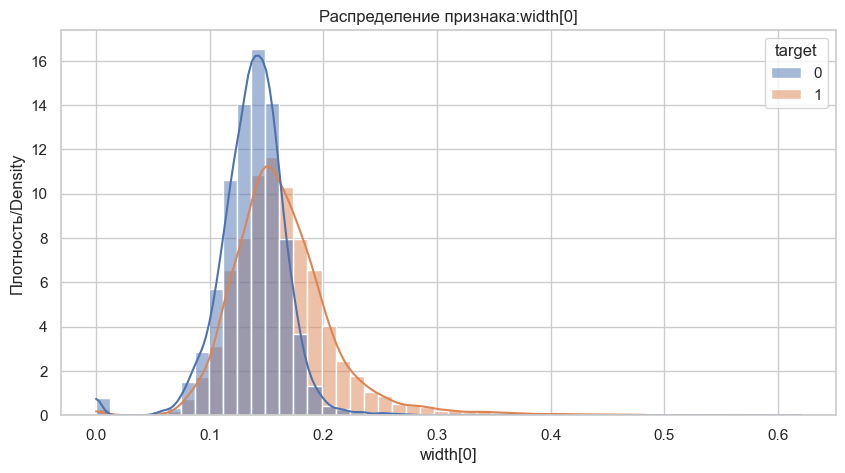

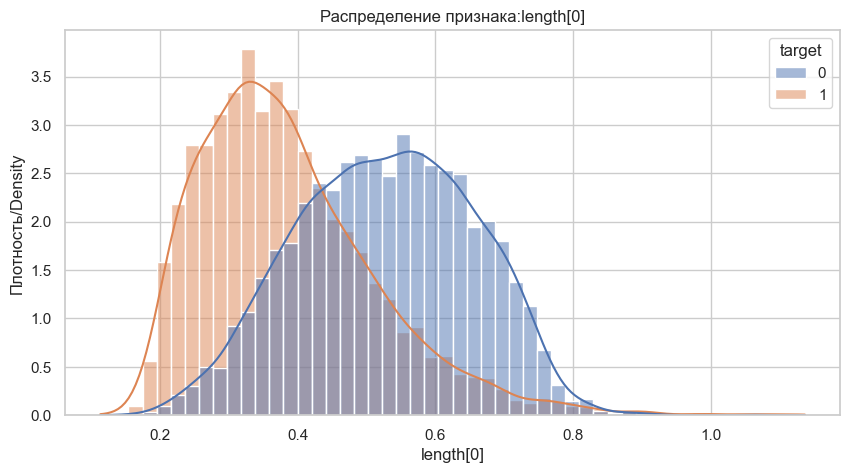

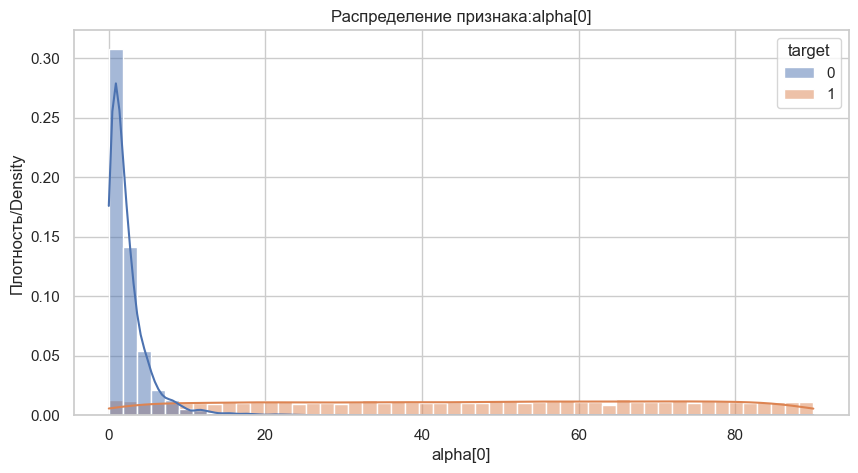

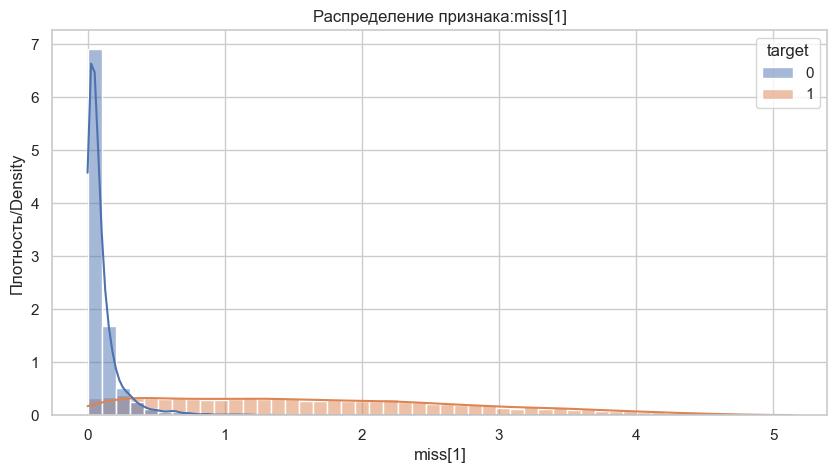

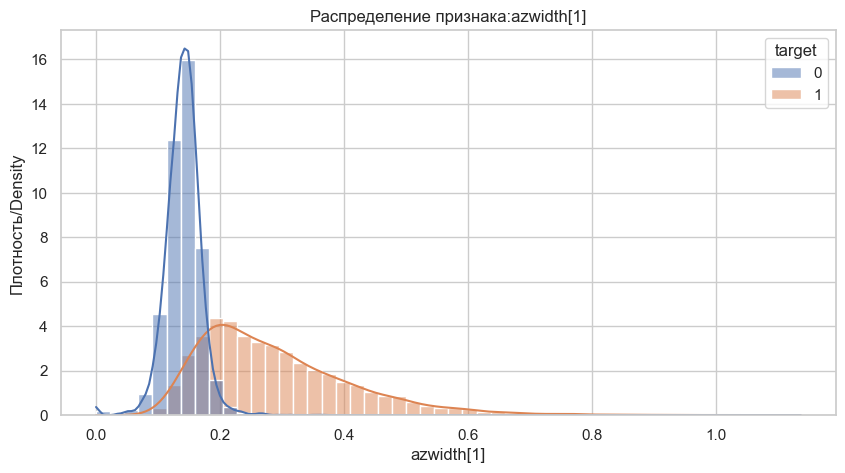

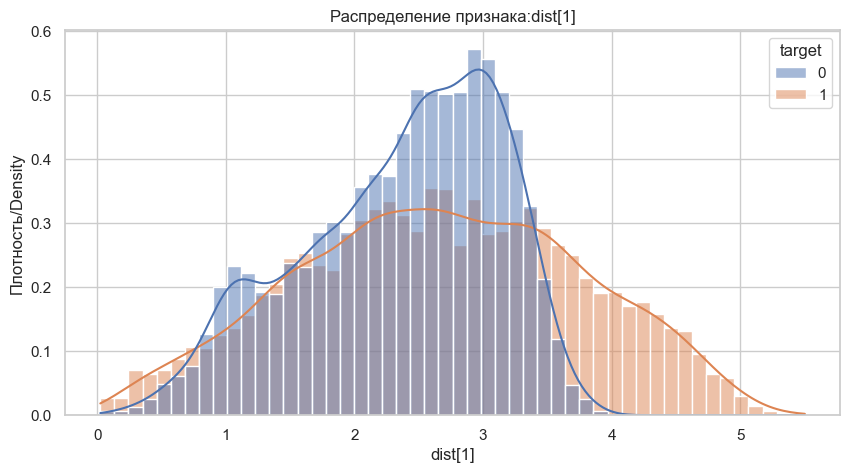

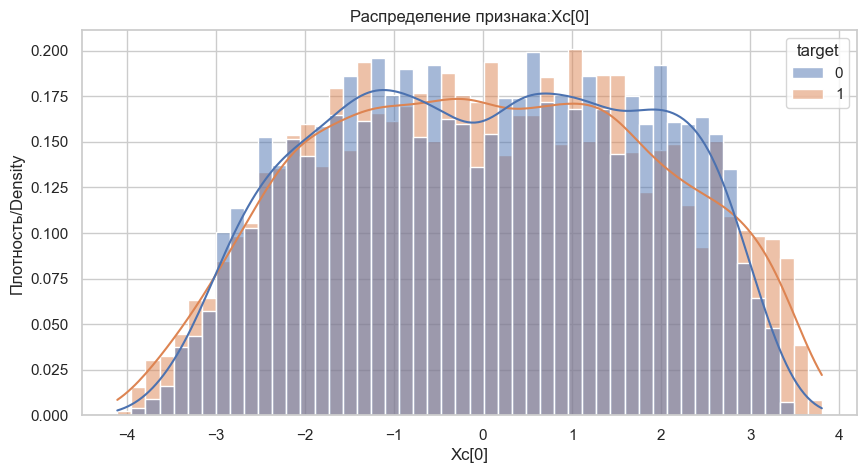

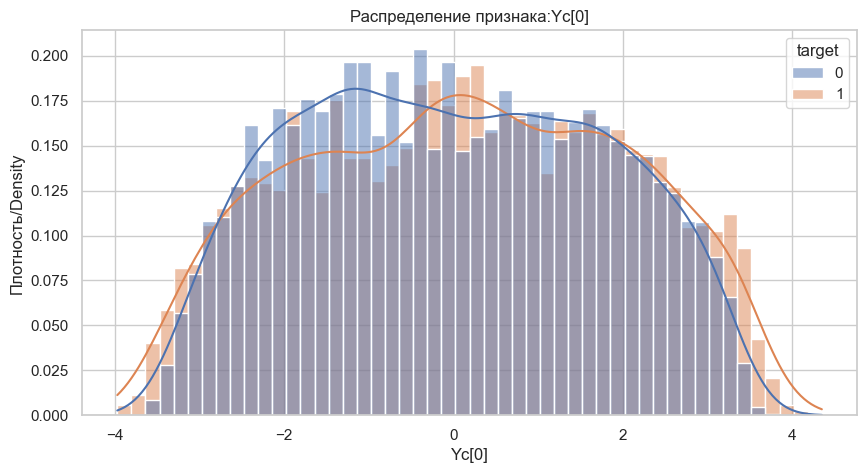

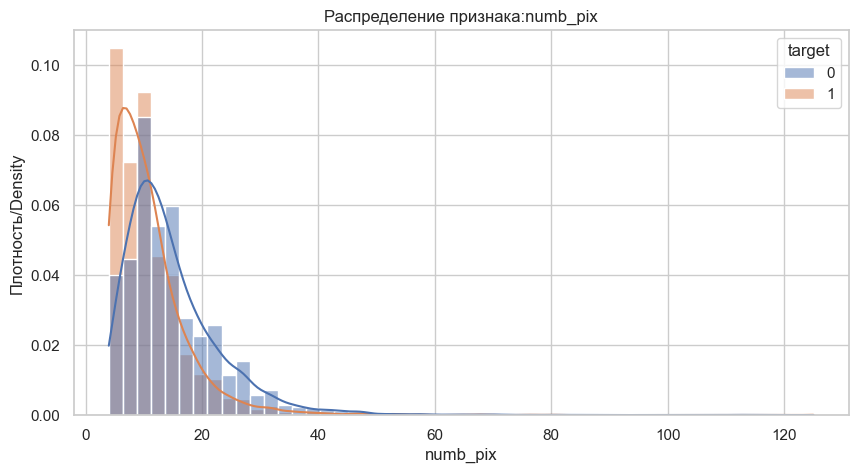

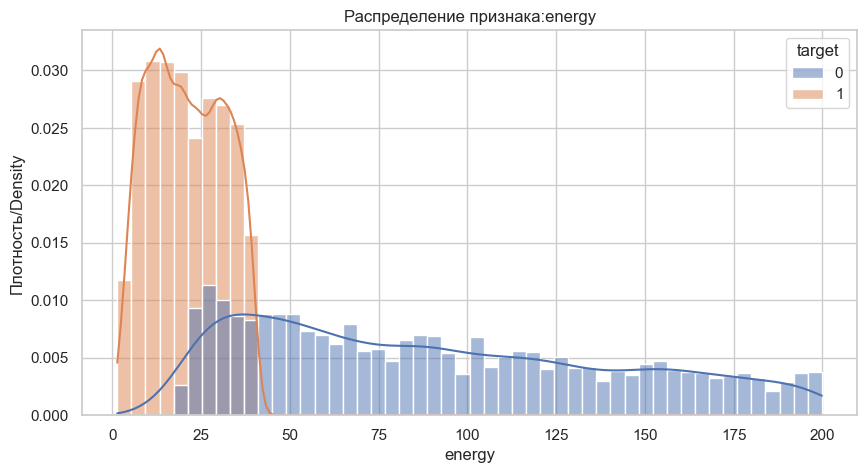

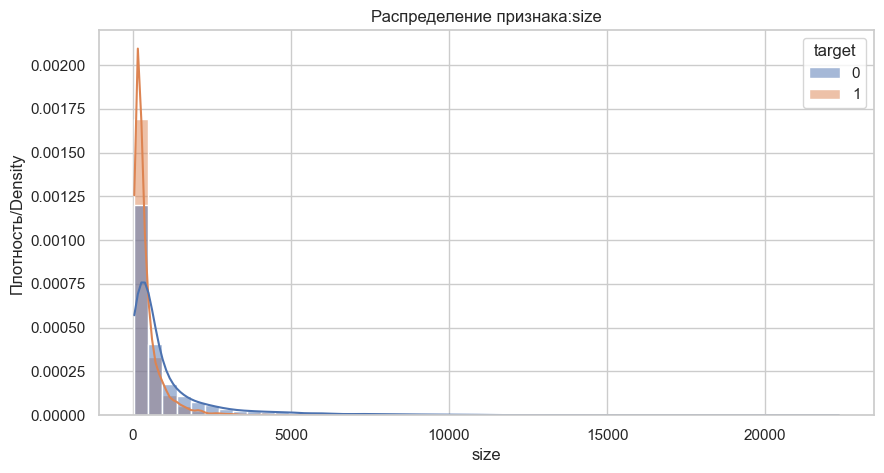

In [33]:
# Подсказки:
# 1. Создайте список features_to_plot с несколькими признаками для анализа.
#    Можно начать с width[0], length[0], alpha[0], miss[1], azwidth[1], dist[1], Xc[0], Yc[0], numb_pix.
# 2. Для каждого признака постройте распределение отдельно для gamma и proton.
# 3. Удобные функции: sns.histplot(..., hue="target") или sns.kdeplot(..., hue="target").
# 4. Настройте bins, alpha, stat="density" и common_norm=False, если используете histplot.
# 5. Подпишите графики и сравните формы распределений.

# Ваш код:
features_to_plot = ['width[0]', 'length[0]', 'alpha[0]', 'miss[1]', 
                    'azwidth[1]', 'dist[1]', 'Xc[0]', 'Yc[0]', 'numb_pix', 
                    'energy', 'size']
for feature in features_to_plot: 
    plt.figure(figsize=(10,5))
    sns.histplot(data=df, x=feature, hue="target", 
                 bins=50, alpha=0.5, stat="density", common_norm=False, kde=True)
    plt.title(f'Распределение признака:{feature}')
    plt.xlabel(feature)
    plt.ylabel("Плотность/Density")

    plt.show()

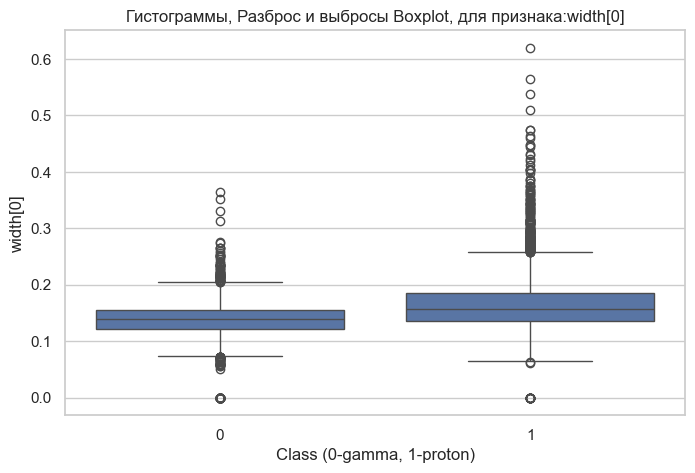

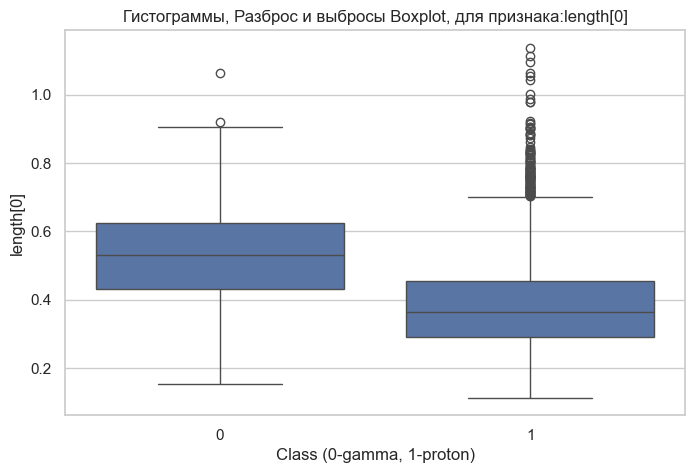

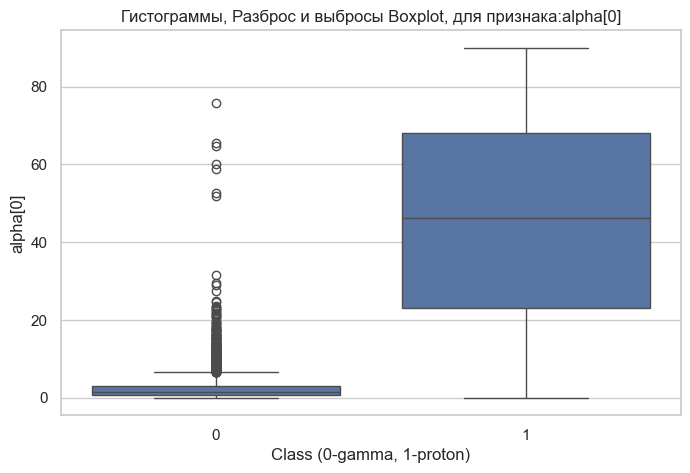

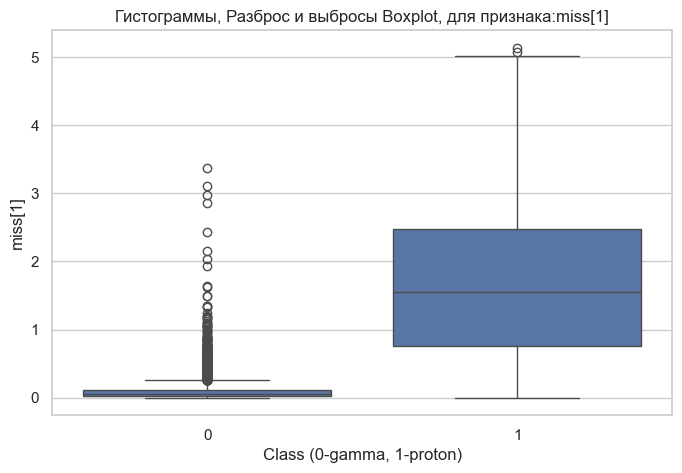

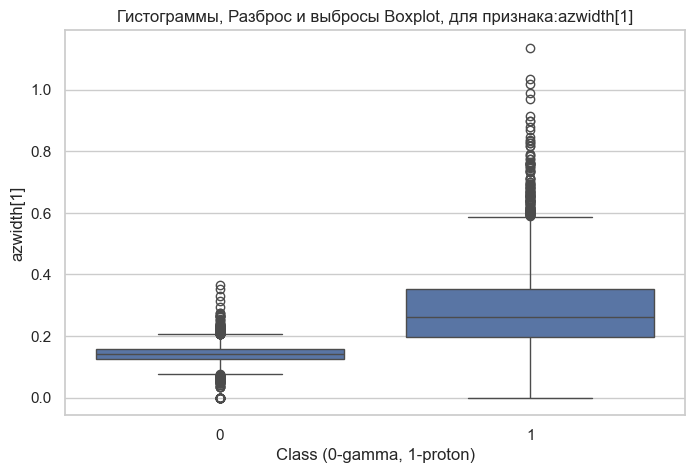

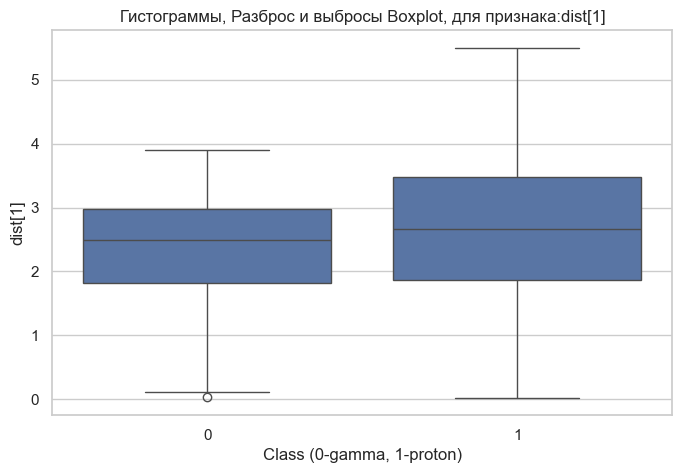

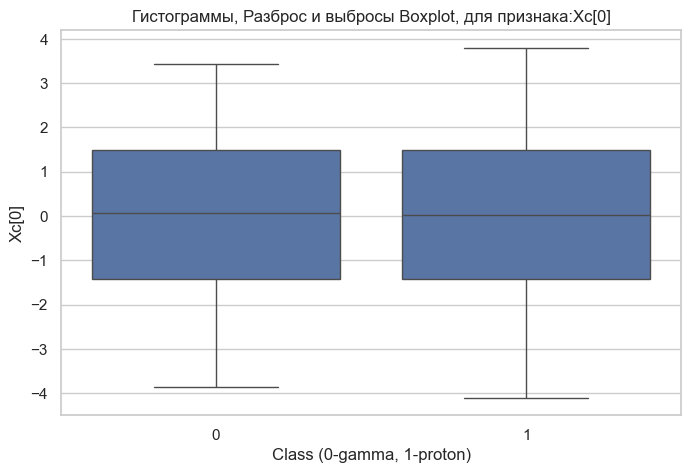

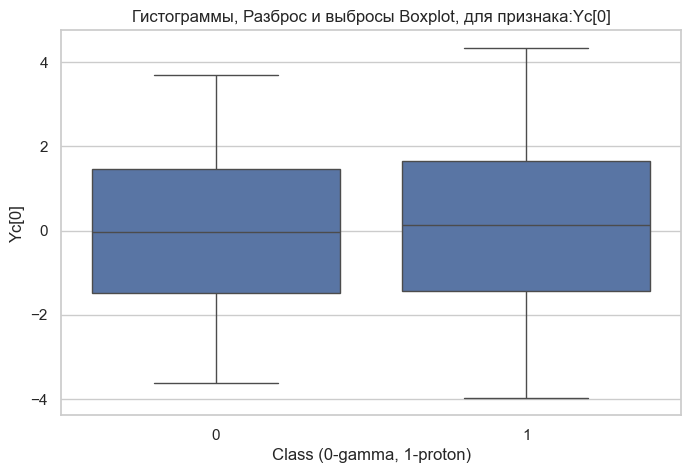

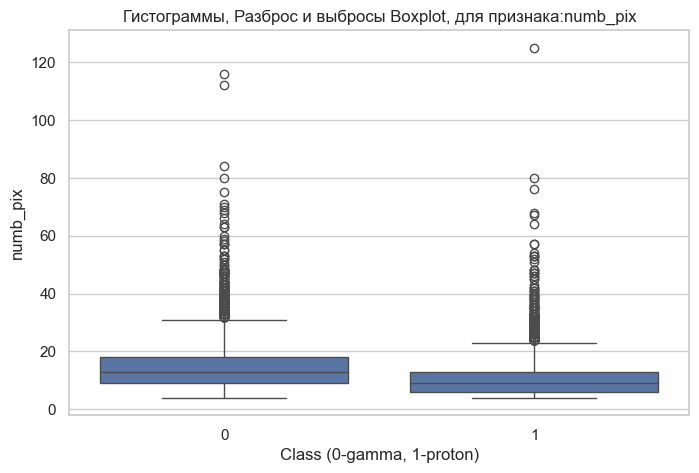

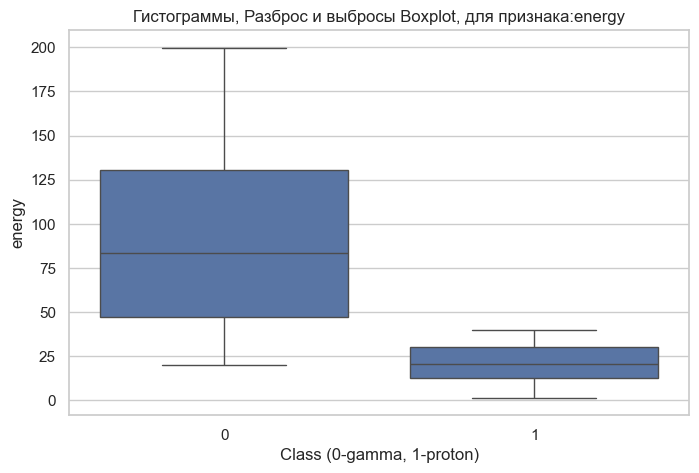

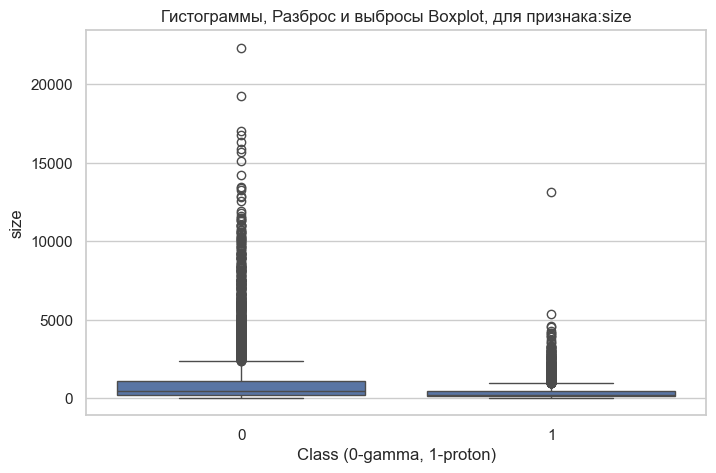

In [36]:
# Подсказки:
# 1. Постройте boxplot или violinplot для тех же признаков.
# 2. Удобные функции: sns.boxplot(data=df, x="target", y=feature) или sns.violinplot(...).
# 3. Используйте цикл по features_to_plot, если хотите построить несколько графиков.
# 4. Обратите внимание на медианы, разброс и выбросы.

# Ваш код:
for feature in features_to_plot: 
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="target", y=feature)
    plt.title(f"Гистограммы, Разброс и выбросы Boxplot, для признака:{feature}")
    plt.xlabel("Class (0-gamma, 1-proton)")
    plt.ylabel(feature)

    plt.show()


### Промежуточный вывод 6

Ответьте:

- Какие признаки имеют заметно разные распределения для `gamma` и `proton`?
- Какие признаки почти не разделяют классы визуально?
- Есть ли признаки с сильными выбросами?
- Какие признаки стоит оставить кандидатами для модели по итогам визуального анализа?

**Ваш вывод:**

> 1) я бы сказал alfa[0], miss[1], azwidth[1], energy, numb_pix, size
> 2) Yc[0], Xc[0], 
> 3) miss[1], alfa[0]
> 4) alfa[0], energy, size, numb_pix, включая остальные Параметры Хилласа (lentgh[0], width[0]);

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> графики для визуального анализа построены хорошо.</span> Есть распределения по обязательным признакам, добавлены свои признаки `energy` и `size`, а также построены boxplot для оценки разброса и выбросов. Вывод, что `alpha[0]`, `miss[1]`, `azwidth[1]`, `numb_pix` и `size` заметно различаются между классами, в целом подтверждается графиками.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> вывод по распределениям стоит сделать содержательнее.</span> Сейчас в основном перечислены признаки. Лучше описывать, как именно отличаются распределения: например, у `gamma` `alpha[0]` и `miss[1]` сильнее сконцентрированы около малых значений, а у `proton` распределения шире и сдвинуты к большим значениям. Такая интерпретация полезнее для выбора признаков, чем простой список.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> `energy` нельзя безоговорочно оставлять кандидатом для модели.</span> Мы отдельно обсуждали риск утечки: проблема не в том, что признак обязан идеально коррелировать с классом, а в том, доступна ли такая информация в реальном применении модели и не получена ли она из недопустимого источника. Поэтому `energy` нужно явно пометить как спорный признак и не включать в кандидаты без дополнительной проверки происхождения.

## Задание 7. Исследовать корреляцию признаков с таргетом

Так как `target` закодирован числами `0` и `1`, обычная корреляция Пирсона между числовым признаком и `target` показывает линейную связь признака с классом.

Интерпретация:

- положительная корреляция: большие значения признака чаще соответствуют `proton`;
- отрицательная корреляция: большие значения признака чаще соответствуют `gamma`;
- корреляция около нуля не означает, что признак бесполезен: связь может быть нелинейной.

In [44]:
# Подсказки:
# 1. Посчитайте корреляцию каждого числового признака с df["target"].
# 2. Удобный метод: .corrwith(...).
# 3. Добавьте колонку с модулем корреляции, чтобы отсортировать признаки по силе связи.
# 4. Сохраните таблицу корреляций в переменную corr_with_target.
# 5. Выведите признаки с самой большой корреляцией по модулю.
# Ваш код:
correlations = df[numeric_columns].corrwith(df['target'])
corr_with_target=correlations.to_frame(name='correlation')
corr_with_target['abs_correlation']=corr_with_target.abs()
corr_with_target = corr_with_target.dropna()
corr_with_target = corr_with_target.sort_values(by="abs_correlation", ascending=False)
display(corr_with_target.head(15))

,correlation,abs_correlation
alpha[0],0.771710,0.771710
alpha[1],0.769074,0.769074
miss[1],0.716817,0.716817
energy,-0.676636,0.676636
azwidth[1],0.651649,0.651649
length[0],-0.482525,0.482525
width[0],0.314517,0.314517
Xmax,-0.248761,0.248761
numb_pix,-0.243875,0.243875
size,-0.243110,0.243110


Text(0, 0.5, 'Признак')

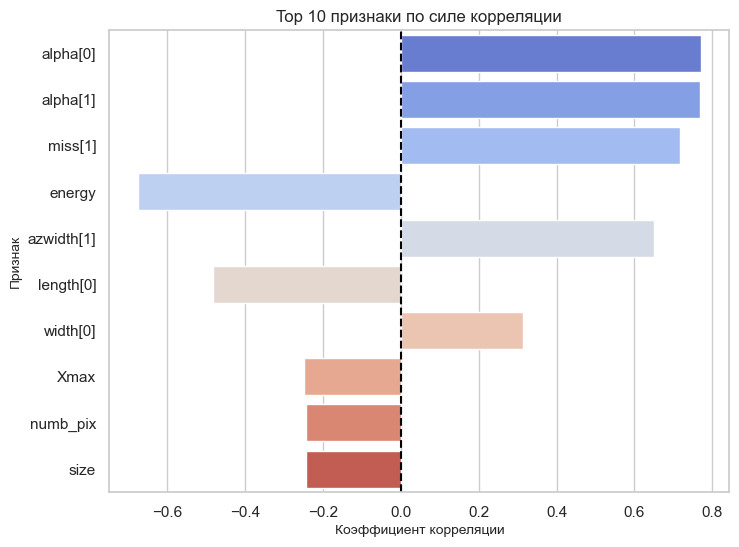

In [46]:
# Подсказки:
# 1. Возьмите top-N признаков из corr_with_target.
# 2. Постройте горизонтальный barplot корреляций.
# 3. Удобная функция: sns.barplot(...).
# 4. Добавьте вертикальную линию x=0 через plt.axvline(0).
# 5. Подпишите оси и заголовок.

# Ваш код:
top_corr = corr_with_target.head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_corr["correlation"], y=top_corr.index, palette="coolwarm")
plt.axvline(0, color="black", linestyle="--", linewidth=1.5)
plt.title("Top 10 признаки по силе корреляции", fontsize=12)
plt.xlabel('Коэффициент корреляции', fontsize=10)
plt.ylabel('Признак', fontsize=10)

### Промежуточный вывод 7

Ответьте:

- Какие признаки сильнее всего связаны с `target` по модулю корреляции?
- Какие признаки имеют положительную корреляцию с `target`, то есть больше характерны для `proton`?
- Какие признаки имеют отрицательную корреляцию с `target`, то есть больше характерны для `gamma`?
- Совпадают ли результаты корреляции с выводами по распределениям?

**Ваш вывод:**

> 1) alfa[0], alfa[1], miss[1], energy, azwidth[1]
> 2) alfa[0], alfa[1], miss[1]
> 3) energy, length[0], size
> 4) да, по идее очень прикольно; 

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> расчет корреляций выполнен корректно.</span> Корреляции посчитаны для `numeric_columns`, добавлен модуль корреляции, таблица отсортирована по силе связи с `target`, а barplot помогает увидеть знак и величину связи. Топ-признаки по модулю в выводе названы в целом правильно: `alpha[0]`, `alpha[1]`, `miss[1]`, `energy`, `azwidth[1]`.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> сравнение с распределениями нужно расписать содержательно.</span> Ответ "да" слишком короткий: стоит указать, какие именно совпадения видны, например `alpha[0]`, `miss[1]` и `azwidth[1]` хорошо разделялись на графиках и одновременно имеют высокую положительную корреляцию с `target`.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> высокая корреляция `energy` с `target` не делает этот признак автоматически допустимым для модели.</span> С учетом риска утечки `energy` нужно отдельно помечать как спорный признак: корреляция показывает связь с классом, но не отвечает на вопрос, можно ли использовать этот источник информации в реальном сценарии.

## Задание 8. Проверить корреляции между признаками

Если два признака почти полностью повторяют друг друга, модель может не получить от них новой информации. Постройте тепловую карту корреляций между наиболее перспективными признаками.

Сначала выберите признаки с наибольшей связью с `target`, затем посмотрите, нет ли среди них сильно коррелирующих пар.

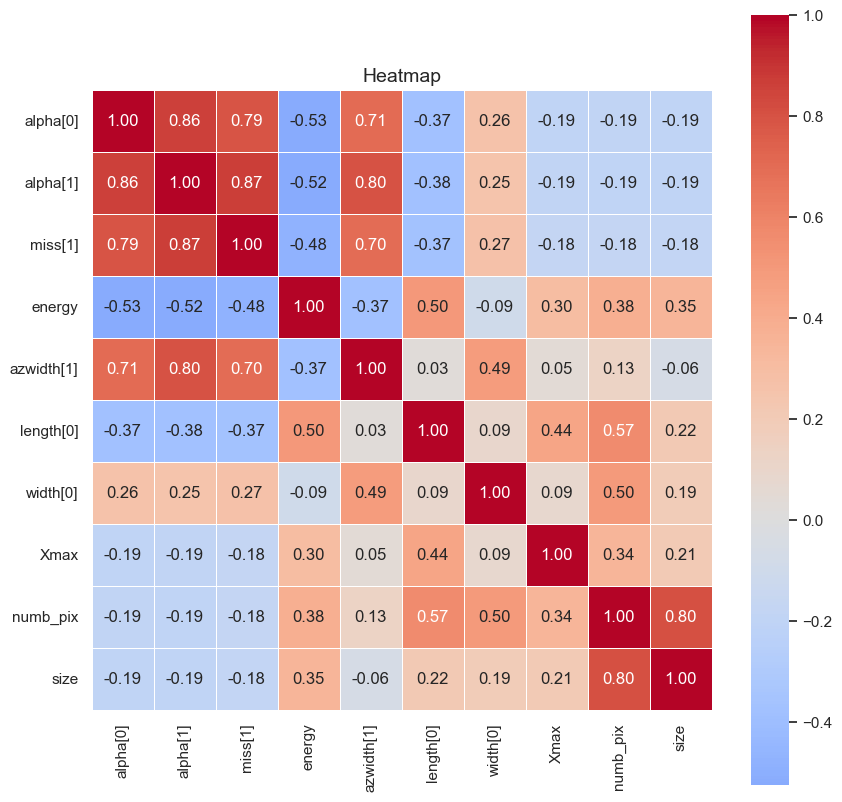

Пары с очень высокой корреляцией (> |0.8|):
- alpha[1] и alpha[0]: 0.86
- miss[1] и alpha[1]: 0.87
- azwidth[1] и alpha[1]: 0.80
- size и numb_pix: 0.80


In [47]:
# Подсказки:
# 1. Выберите 10-15 наиболее перспективных признаков.
# 2. Посчитайте матрицу корреляций между ними через .corr().
# 3. Постройте heatmap через sns.heatmap(...).
# 4. Найдите пары признаков с очень высокой корреляцией между собой.

# Ваш код:
top_features = corr_with_target.head(10).index.tolist()
corr_matrix = df[top_features].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap', fontsize=14)
plt.show()

print("Пары с очень высокой корреляцией (> |0.8|):")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"- {corr_matrix.columns[i]} и {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")

### Промежуточный вывод 8

Ответьте:

- Есть ли пары признаков с очень высокой корреляцией между собой?
- Нужно ли удалять один из таких признаков уже сейчас или лучше оставить решение до этапа обучения моделей?
- Какие признаки после этого шага остаются наиболее перспективными?

**Ваш вывод:**
>1) геометрические характеристики: параметры вторичного острова сильно зависят друг от друга и от главного следа
alpha[1] и alpha[0]: 0.86
 miss[1] и alpha[1]: 0.87
 azwidth[1] и alpha[1]: 0.80 
size и numb_pix: 0.80 суммарная яркость ливня напрямую зависит от количества засвеченных пикселей.
>2) Думаю щас не стоит, если потом плохо будет с моделью можно проэксперементировать; Лучше недосолить еду нежеои чем пересолить) ведь потом можно уже соли добавить по мере необходимости) Тут также потом можно будет удалить;
>3) Наиболее перспективными остаются независимые лидеры из разных "групп" характеристик: alpha[0] (главный показатель геометрии и формы основного ливня), а также miss[1] (лучшая описательная метрика для вторичного острова); 


<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> задание выполнено хорошо.</span> Топ-признаки выбраны по модулю корреляции с `target`, построена heatmap, а пары с высокой корреляцией явно выведены кодом. Найденные пары `alpha[1]`/`alpha[0]`, `miss[1]`/`alpha[1]`, `azwidth[1]`/`alpha[1]` и `size`/`numb_pix` соответствуют расчетам. Решение не удалять признаки сразу, а вернуться к этому на этапе обучения моделей, здесь выглядит разумно.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> аккуратнее с формулировкой "независимые лидеры".</span> Например, `alpha[0]` и `miss[1]` коррелируют примерно на `0.79`, то есть они не полностью независимы, а просто немного ниже выбранного порога `0.8`.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> вывод про "вторичный остров" звучит слишком уверенно для одной heatmap.</span> По этой таблице надежнее сказать, что группа геометрических признаков сильно связана между собой; физическую интерпретацию лучше подтверждать описанием признаков и предыдущими графиками.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> итоговый список перспективных признаков после этого шага стоит сделать шире.</span> В ответе названы только `alpha[0]` и `miss[1]`, но по графикам и корреляциям также остаются интересными `azwidth[1]`, `length[0]`, `width[0]`, `numb_pix`/`size` с учетом их связей между собой.

## Задание 9. Сформировать итоговый набор признаков

Соберите итоговый список `selected_features` для следующей работы с моделями.

Критерии выбора:

- признак есть и у `gamma`, и у `proton`;
- признак числовой;
- признак не является `target` или идентификатором события;
- распределения признака отличаются между классами или есть заметная связь с `target`;
- если признак исключен, вы можете объяснить почему.

In [48]:
# Подсказки:
# 1. Создайте список selected_features вручную по итогам предыдущих заданий.
# 2. В список должны попасть только признаки, которые есть в df и подходят для модели.
# 3. Не включайте target и идентификаторы событий.
# 4. Проверьте список: все выбранные признаки должны быть в numeric_columns.
# 5. Выведите итоговый список и его длину.

# Ваш код:
selected_features = ['alpha[0]', 
    'length[0]',  
    'width[0]',   
    'miss[1]',    
    'azwidth[1]', 
    'size',       
    'numb_pix',  
    'Xmax'
]
try:
    check_numeric = all(f in numeric_columns for f in selected_features)
    print(f"Все выбранные признаки являются числовыми: {check_numeric}\n")
except NameError:
    pass 
print("Итоговый список признаков для модели:")
for feature in selected_features:
    print(f"- {feature}")
print("\nКоличество итоговых признаков:", len(selected_features))

Все выбранные признаки являются числовыми: True

Итоговый список признаков для модели:
- alpha[0]
- length[0]
- width[0]
- miss[1]
- azwidth[1]
- size
- numb_pix
- Xmax

Количество итоговых признаков: 8


## Итоговый вывод

Заполните в конце работы:

1. Какие файлы были считаны и как был задан `target`?
2. Какие признаки визуально лучше всего разделяют `gamma` и `proton`?
3. Какие признаки сильнее всего коррелируют с `target`?
4. Какие признаки были исключены и почему?
5. Какой итоговый список `selected_features` вы предлагаете использовать для обучения моделей?

**Ваш итоговый вывод:**

> 1)  файлы с данными наблюдений черенковского телескопа. Данные в csv формате: gamma and proton отдельные датасеты; target это целевая переменная чтобы отличать цели гамма квантов от протонов. Гамма квантам присвоен 0; proton один;
> 2)  Визуально (на гистограммах и графиках плотности) лучше всего классы разделяют геометрические параметры направленности ливня — в первую очередь alpha[0] и miss[1]. Распределения этих признаков для гамма-квантов имеют ярко выраженные пики около нуля, тогда как для протонов они распределены более равномерно.
> 3)  Какие признаки сильнее всего коррелируют с target?
Согласно анализу, в топ-5 признаков по модулю корреляции вошли: alpha[0] (0.77) alpha[1] (0.76) miss[1] (0.71) energy (-0.67) azwidth[1] (0.65)
> 4) energy: исключен из-за высокого риска утечки данных (Data Leakage). В реальных условиях истинная энергия первичной частицы не измеряется телескопом напрямую в момент вспышки, поэтому использование этого признака сделает модель нежизнеспособной на новых данных.  alpha[1]: исключен из-за сильной мультиколлинеарности. Его корреляция с alpha[0] и miss[1] превышает 0.85, что делает его избыточным. Модели будет достаточно параметра miss[1];Координатные признаки (Xc, Yc, dist и т.д.): исключены из-за того, что их корреляция с target близка к нулю (меньше 0.1), они представляют собой скорее визуальный шум. Идентификаторы и сам target: исключены, так как не являются предикторами.
> 5) ИТОГ: Для дальнейшего обучения моделей предлагается использовать список из 8 наиболее сильных и независимых аппаратных признаков:
['alpha[0]', 'length[0]', 'width[0]', 'miss[1]', 'azwidth[1]', 'size', 'numb_pix', 'Xmax'] НО! я не знаю точно) просто это самое логичное что я вывел лол

## Общие впечатления по проверке

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Общее впечатление:</b> Хакназар показал очень высокий уровень владения Python и сильное аналитическое мышление.</span> Видно, что код пишется уверенно, основные проверки выполняются последовательно, а выводы не сводятся только к механическому перечислению команд.

Основные замечания сейчас относятся не к владению инструментами, а к исследовательской дисциплине: нужно точнее связывать выводы с конкретными колонками, аккуратнее обращаться со спорными признаками, явно проверять происхождение признаков и не делать сильных утверждений без подтверждения кодом или числами. Если к этим способностям добавить больше практики, получится очень сильный результат.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Задание 9:</b> итоговый выбор `selected_features` проверим после исправления замечаний выше.</span> Сейчас важно сначала поправить логику отбора признаков и комментарии к спорным колонкам, а затем уже финально оценивать итоговый список.

Ждем исправлений и желаем успехов.